# Lab 5: Regularization

Inspect -> split -> scale -> fit four models -> compare coefficients and test errors.
The model settings match the source notebook. It reports duplicates and outliers
without removing them.

The source scales the training set before internal CV. This keeps the test set
separate, but CV folds share scaling statistics. For strict CV, fit a scaler inside
each fold using a Pipeline and GridSearchCV. This practice version retains the lab procedure.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.metrics import mean_squared_error, r2_score


## 1. Load the local copy of the UCI red-wine data

In [2]:
df = pd.read_csv("winequality-red.csv", sep=";")
print("Shape:", df.shape)
print("Missing:", df.isna().sum().sum(), "Duplicates:", df.duplicated().sum())
df.head()


Shape: (1599, 12)
Missing: 0 Duplicates: 240


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## 2. EDA — IQR outliers + correlation

Outliers by IQR rule:
 residual sugar          155
chlorides               112
sulphates                59
total sulfur dioxide     55
fixed acidity            49
density                  45
pH                       35
free sulfur dioxide      30
volatile acidity         19
alcohol                  13
citric acid               1
dtype: int64


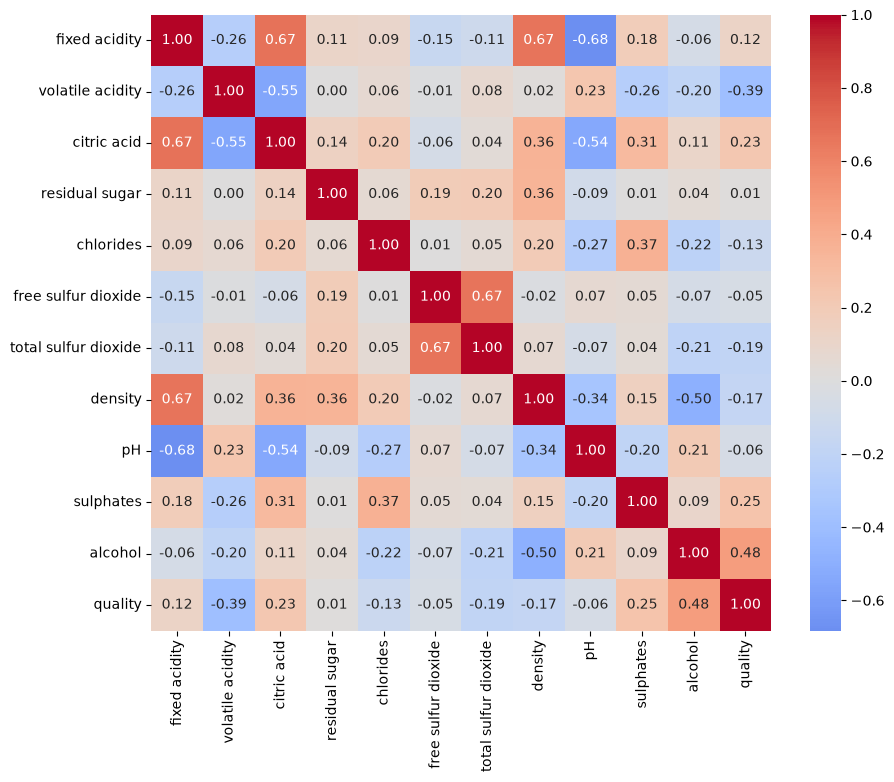

In [3]:
features = df.drop(columns="quality")
q1,q3 = features.quantile(0.25), features.quantile(0.75)
iqr = q3-q1
outliers = ((features < q1-1.5*iqr) | (features > q3+1.5*iqr)).sum()
print("Outliers by IQR rule:\n", outliers.sort_values(ascending=False))
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.show()


## 3. Split + scale

In [4]:
X = df.drop(columns="quality")
y = df["quality"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
sc = StandardScaler()
X_train_s = sc.fit_transform(X_train)
X_test_s  = sc.transform(X_test)
print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (1279, 11) Test: (320, 11)


## 4. Fit four models (CV picks alpha)

In [5]:
alphas = np.logspace(-4, 2, 15)
linear  = LinearRegression()
ridge   = RidgeCV(alphas=alphas, cv=5, scoring="neg_mean_squared_error")
lasso   = LassoCV(alphas=alphas, cv=5, max_iter=50000, random_state=42)
elastic = ElasticNetCV(alphas=alphas, l1_ratio=[0.2,0.5,0.8], cv=5, max_iter=50000, random_state=42)
for m in (linear, ridge, lasso, elastic): m.fit(X_train_s, y_train)
print("Ridge alpha:", ridge.alpha_)
print("Lasso alpha:", round(lasso.alpha_,4))
print("ElasticNet alpha:", round(elastic.alpha_,4), "l1_ratio:", elastic.l1_ratio_)


Ridge alpha: 100.0
Lasso alpha: 0.0052
ElasticNet alpha: 0.0139 l1_ratio: 0.5


## 5. Coefficients — Lasso/ElasticNet zero weak features out

In [6]:
coef = pd.DataFrame({"Linear":linear.coef_, "Ridge":ridge.coef_,
                     "Lasso":lasso.coef_, "ElasticNet":elastic.coef_}, index=X.columns)
print(coef.round(4))
print("\nZero coefficients:\n", (coef.abs() < 1e-8).sum())


                      Linear   Ridge   Lasso  ElasticNet
fixed acidity         0.0398  0.0541  0.0103      0.0106
volatile acidity     -0.1794 -0.1647 -0.1711     -0.1705
citric acid          -0.0275 -0.0040 -0.0016     -0.0000
residual sugar        0.0094  0.0165  0.0000      0.0000
chlorides            -0.0891 -0.0843 -0.0857     -0.0822
free sulfur dioxide   0.0580  0.0447  0.0463      0.0396
total sulfur dioxide -0.1200 -0.1083 -0.1104     -0.1038
density              -0.0192 -0.0469 -0.0000     -0.0000
pH                   -0.0606 -0.0382 -0.0580     -0.0531
sulphates             0.1468  0.1400  0.1374      0.1344
alcohol               0.2966  0.2623  0.3006      0.2976

Zero coefficients:
 Linear        0
Ridge         0
Lasso         2
ElasticNet    3
dtype: int64


## 6. Test-set comparison

In [7]:
rows = []
for name,m in {"Linear":linear,"Ridge":ridge,"Lasso":lasso,"ElasticNet":elastic}.items():
    p = m.predict(X_test_s)
    rows.append({"Model":name, "MSE":mean_squared_error(y_test,p), "R2":r2_score(y_test,p)})
print(pd.DataFrame(rows).set_index("Model").round(4))


               MSE      R2
Model                     
Linear      0.3900  0.4032
Ridge       0.3927  0.3991
Lasso       0.3921  0.4001
ElasticNet  0.3927  0.3991


## Extra EDA plots from the lab

Include these if the question asks for feature distributions or alcohol versus quality.

       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1599.000000       1599.000000  1599.000000     1599.000000   
mean        8.319637          0.527821     0.270976        2.538806   
std         1.741096          0.179060     0.194801        1.409928   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.390000     0.090000        1.900000   
50%         7.900000          0.520000     0.260000        2.200000   
75%         9.200000          0.640000     0.420000        2.600000   
max        15.900000          1.580000     1.000000       15.500000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  1599.000000          1599.000000           1599.000000  1599.000000   
mean      0.087467            15.874922             46.467792     0.996747   
std       0.047065            10.460157             32.895324     0.001887   
min       0.012000             1.000000         

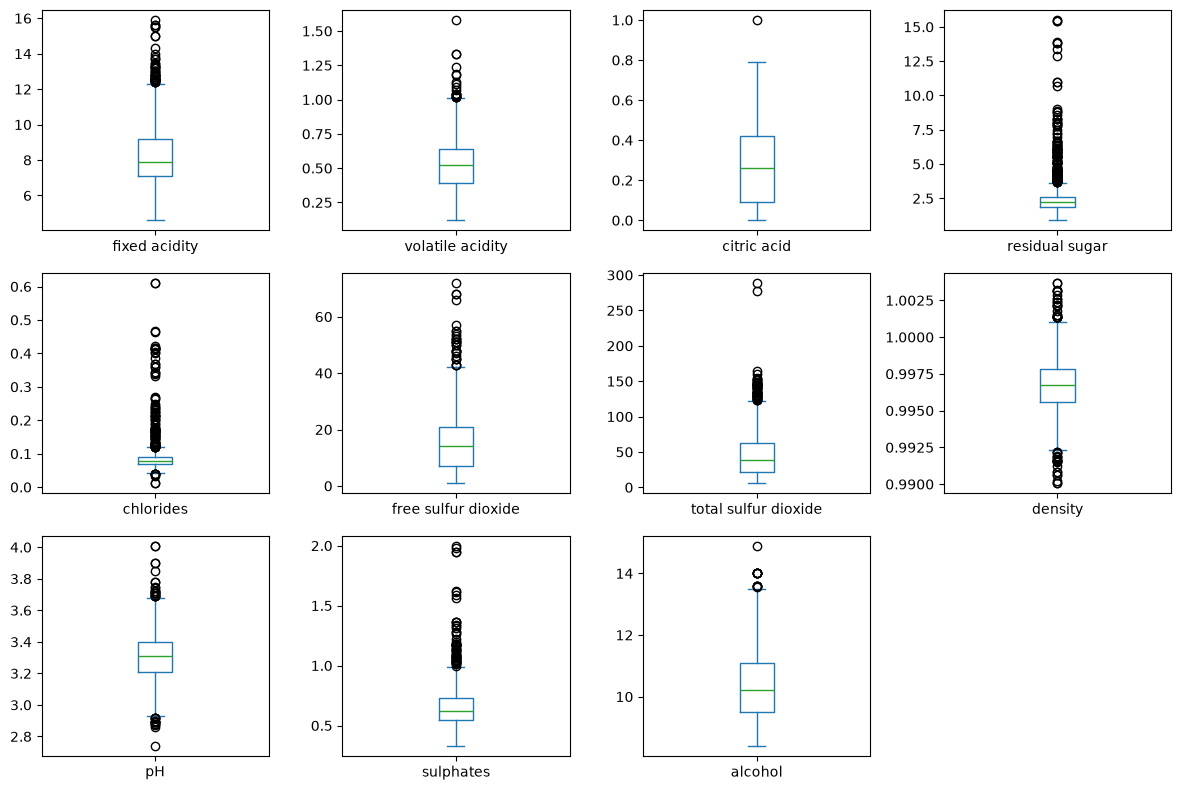

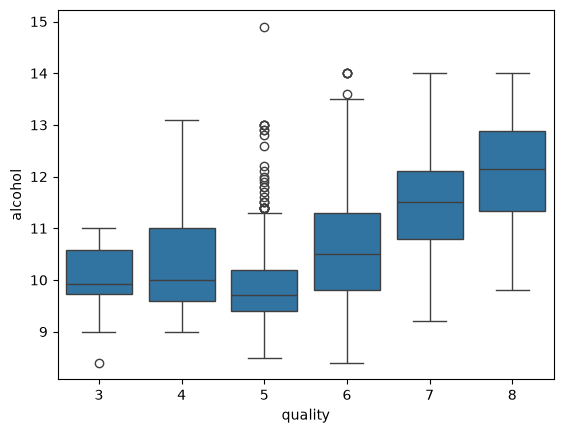

In [8]:
print(df.describe())
features.plot(kind="box", subplots=True, layout=(3, 4), figsize=(12, 8))
plt.tight_layout()
plt.show()
sns.boxplot(data=df, x="quality", y="alcohol")
plt.show()
